# **Evaluación Parcial N° 1:** Clasificación de Prendas con Deep Learning
Asignatura: Deep Learning

**Dataset:** Fashion-MNIST

**Objetivo:** Implementar y optimizar una red neuronal artificial multicapa (MLP) para clasificar imágenes de ropa en 10 categorías.

**Nombres:** Nicolas Saldivia, Patricio Marquez


# 1.Configuración del Entorno
Importamos las librerías esenciales: TensorFlow y Keras para la construcción de la red, Matplotlib para la visualización y Scikit-learn para el cálculo de métricas de desempeño.

In [ ]:
# Importamos las librerías básicas para manejo de datos y gráficos
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos TensorFlow y Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

print("Librerías importadas correctamente. Versión de TensorFlow:", tf.__version__)# Importamos las librerías básicas para manejo de datos y gráficos
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos TensorFlow y Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

print("Librerías importadas correctamente. Versión de TensorFlow:", tf.__version__)

Librerías importadas correctamente. Versión de TensorFlow: 2.20.0
Librerías importadas correctamente. Versión de TensorFlow: 2.20.0


# 2. Carga y Exploración de Datos
Utilizamos el dataset Fashion-MNIST, que contiene 70,000 imágenes en escala de grises. Visualizamos las primeras muestras para comprender las categorías que el modelo deberá identificar (camisetas, bolsos, calzado, etc.).

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Formato de datos de entrenamiento: (60000, 28, 28) (60,000 imágenes de 28x28 píxeles)
Formato de datos de prueba: (10000, 28, 28) (10,000 imágenes de 28x28 píxeles)


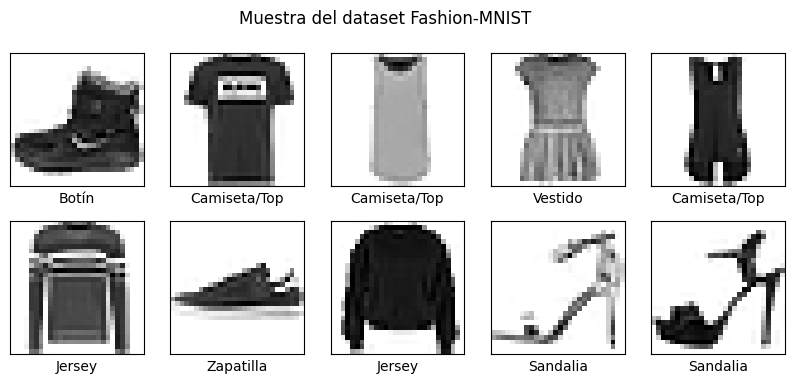

In [ ]:
# Cargamos el dataset directamente desde Keras
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Nombres de las clases (categorías de ropa) según la documentación oficial
class_names = ['Camiseta/Top', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

print(f"Formato de datos de entrenamiento: {X_train.shape} (60,000 imágenes de 28x28 píxeles)")
print(f"Formato de datos de prueba: {X_test.shape} (10,000 imágenes de 28x28 píxeles)")

# Visualizamos algunas imágenes para entender los datos (¡Muy útil para tu presentación!)
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.suptitle('Muestra del dataset Fashion-MNIST')
plt.show()

# 3. Preprocesamiento de Datos
Para que la red neuronal procese la información correctamente, realizamos dos pasos críticos:

Normalización: Escalamos los valores de los píxeles (0-255) al rango [0, 1] para mejorar la convergencia.

Aplanamiento (Flatten): Convertimos las matrices de 28x28 en vectores de 784 neuronas, requisito fundamental para un Perceptrón Multicapa (MLP).

In [ ]:
# 1. Normalización: Los píxeles van de 0 a 255. Los dividimos por 255.0 para que queden entre 0 y 1.
# Esto ayuda a que la red neuronal aprenda más rápido y de forma más estable.
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# 2. Aplanamiento (Flattening): Convertimos cada matriz de 28x28 en un vector de 784 elementos.
# El MLP clásico no entiende de imágenes cuadradas, solo de listas de números.
X_train_flat = X_train_norm.reshape(-1, 28*28)
X_test_flat = X_test_norm.reshape(-1, 28*28)

print(f"Nuevo formato de entrenamiento (aplanado): {X_train_flat.shape}")
print(f"Nuevo formato de prueba (aplanado): {X_test_flat.shape}")

Nuevo formato de entrenamiento (aplanado): (60000, 784)
Nuevo formato de prueba (aplanado): (10000, 784)


# 4. Arquitectura del Modelo Básico
Definimos una red inicial con dos capas ocultas y funciones de activación ReLU. La capa de salida utiliza Softmax para entregar una distribución de probabilidad sobre las 10 clases posibles.

In [ ]:
# Función para crear un Perceptrón Multicapa (MLP) básico
def construir_modelo_basico():
    modelo = Sequential()
    # Capa de entrada (784 neuronas) y primera capa oculta (128 neuronas) con función de activación ReLU
    modelo.add(Dense(128, input_dim=784, activation='relu'))

    # Segunda capa oculta (64 neuronas)
    modelo.add(Dense(64, activation='relu'))

    # Capa de salida (10 neuronas, una por clase). Usamos 'softmax' para clasificación multiclase.
    modelo.add(Dense(10, activation='softmax'))

    # Compilamos indicando la función de pérdida y el optimizador
    modelo.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return modelo

modelo_basico = construir_modelo_basico()
modelo_basico.summary() # Esto mostrará un resumen de la arquitectura de la red

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamos el modelo básico y guardamos el historial para los gráficos
print("Iniciando el entrenamiento del Modelo Básico...")
historial_basico = modelo_basico.fit(
    X_train_flat,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2, # Usa 20% de los datos para validar en cada época
    verbose=1
)
print("¡Entrenamiento básico finalizado!")

Iniciando el entrenamiento del Modelo Básico...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8120 - loss: 0.5427 - val_accuracy: 0.8462 - val_loss: 0.4365
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8563 - loss: 0.3948 - val_accuracy: 0.8635 - val_loss: 0.3788
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8714 - loss: 0.3513 - val_accuracy: 0.8673 - val_loss: 0.3726
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8810 - loss: 0.3226 - val_accuracy: 0.8723 - val_loss: 0.3486
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8884 - loss: 0.3017 - val_accuracy: 0.8800 - val_loss: 0.3392
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8925 - loss: 0.2883 - val_accuracy: 0.8748 - val_loss: 0.3413
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8965 - loss: 0.2766 - val_accuracy: 0.8767 - val_loss: 0.3520
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - ac

# 5. Optimización y Regularización
Para mejorar el rendimiento y evitar el Overfitting (sobreajuste), implementamos:

Batch Normalization: Para estabilizar y acelerar el entrenamiento.

Dropout (0.3): Para desactivar neuronas al azar, forzando a la red a aprender características más robustas.

In [ ]:
# Función para crear el modelo optimizado
def construir_modelo_optimizado():
    modelo = Sequential()

    # Capa de entrada y primera oculta con optimización
    modelo.add(Dense(128, input_dim=784, activation='relu'))
    modelo.add(BatchNormalization()) # Normaliza los datos entre capas
    modelo.add(Dropout(0.3))         # Apaga el 30% de las neuronas para evitar sobreajuste

    # Segunda capa oculta con optimización
    modelo.add(Dense(64, activation='relu'))
    modelo.add(BatchNormalization())
    modelo.add(Dropout(0.3))

    # Capa de salida
    modelo.add(Dense(10, activation='softmax'))

    modelo.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return modelo

modelo_optimizado = construir_modelo_optimizado()

print("Iniciando el entrenamiento del Modelo Optimizado...")
historial_optimizado = modelo_optimizado.fit(
    X_train_flat,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
print("¡Entrenamiento optimizado finalizado!")

Iniciando el entrenamiento del Modelo Optimizado...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7739 - loss: 0.6554 - val_accuracy: 0.8334 - val_loss: 0.4591
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8259 - loss: 0.4931 - val_accuracy: 0.8499 - val_loss: 0.4124
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8372 - loss: 0.4571 - val_accuracy: 0.8493 - val_loss: 0.4098
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8440 - loss: 0.4343 - val_accuracy: 0.8635 - val_loss: 0.3735
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8481 - loss: 0.4243 - val_accuracy: 0.8676 - val_loss: 0.3667
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8541 - loss: 0.4079 - val_accuracy: 0.8558 - val_loss: 0.4030
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8545 - loss: 0.4033 - val_accuracy: 0.8627 - val_loss: 0.3845
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step 

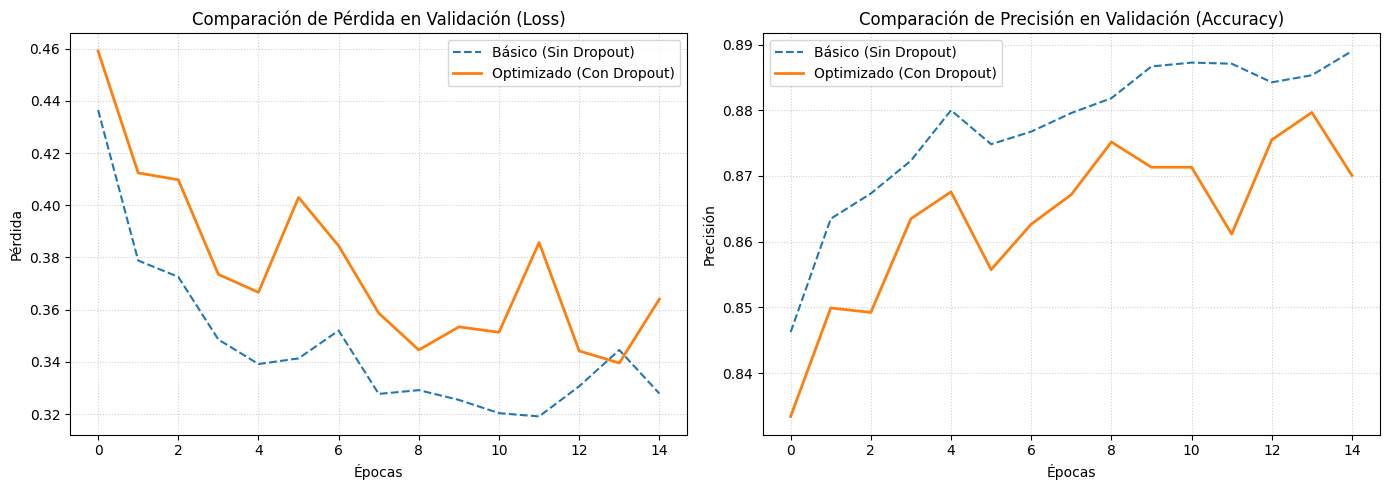

# 6. Evaluación de Desempeño
Analizamos el modelo final mediante la Matriz de Confusión y un reporte detallado que incluye Precision, Recall y F1-Score, permitiéndonos identificar qué prendas son más difíciles de clasificar para el modelo.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

Camiseta/Top       0.87      0.79      0.83      1000
    Pantalón       0.99      0.95      0.97      1000
      Jersey       0.79      0.71      0.75      1000
     Vestido       0.82      0.92      0.87      1000
      Abrigo       0.65      0.89      0.75      1000
    Sandalia       0.97      0.92      0.95      1000
      Camisa       0.73      0.53      0.61      1000
   Zapatilla       0.92      0.96      0.94      1000
       Bolso       0.95      0.97      0.96      1000
       Botín       0.94      0.95      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



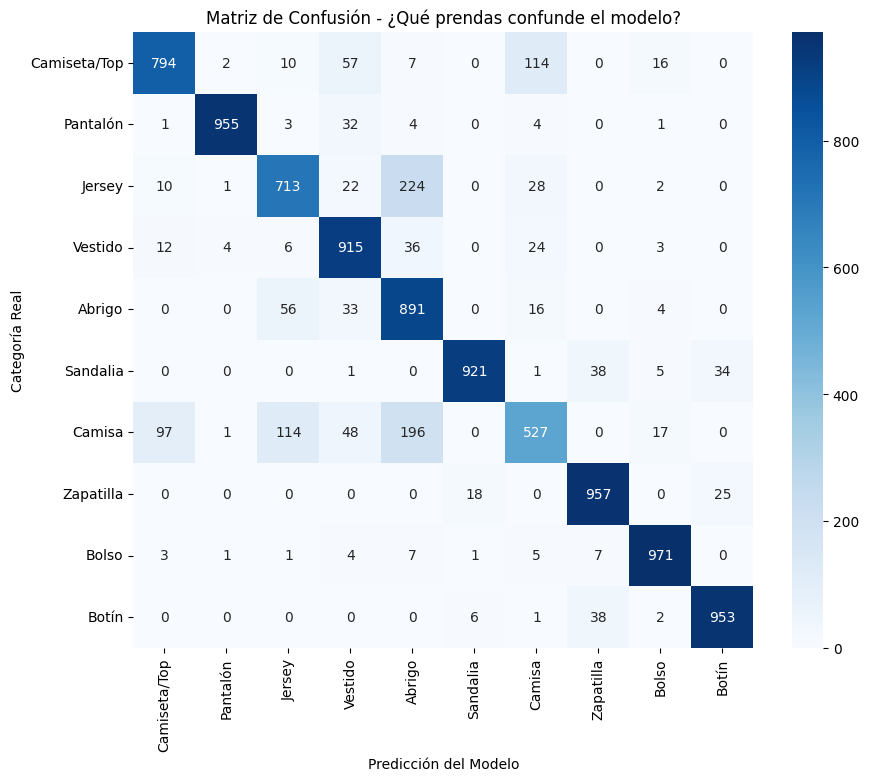

In [ ]:
# Importamos NumPy para manejar los arrays de las predicciones
import numpy as np

# 1. Hacemos las predicciones con los datos de prueba
y_pred_prob = modelo_optimizado.predict(X_test_flat)
y_pred = np.argmax(y_pred_prob, axis=1) # Tomamos la clase con mayor probabilidad

# 2. Imprimimos el Reporte de Clasificación (Aquí están tus métricas)
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# 3. Generamos la Matriz de Confusión (¡Este gráfico dejará encantado a tu profesor!)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Categoría Real')
plt.title('Matriz de Confusión - ¿Qué prendas confunde el modelo?')
plt.show()

# 7. Experimentación de Hiperparámetros
Realizamos pruebas variando la función de activación y la tasa de aprendizaje (Learning Rate) para demostrar empíricamente cómo estos parámetros afectan la capacidad de aprendizaje de la red.

In [ ]:
# 1. EXPERIMENTO: Comparar función de activación (ReLU vs Sigmoid)
print("Entrenando modelo con función Sigmoid para comparar...")
modelo_sigmoid = Sequential([
    Dense(128, input_dim=784, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(10, activation='softmax')
])
modelo_sigmoid.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Entrenamos por menos épocas solo para comparar rápido
modelo_sigmoid.fit(X_train_flat, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=0)
loss_sig, acc_sig = modelo_sigmoid.evaluate(X_test_flat, y_test, verbose=0)

# Evaluamos el modelo básico (ReLU) que ya teníamos entrenado
loss_relu, acc_relu = modelo_basico.evaluate(X_test_flat, y_test, verbose=0)

# 2. EXPERIMENTO: Variar un hiperparámetro (Learning Rate Alto = 0.05)
print("Entrenando modelo con Learning Rate alto (0.05)...")
modelo_lr_alto = Sequential([
    Dense(128, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
modelo_lr_alto.compile(optimizer=Adam(learning_rate=0.05), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
modelo_lr_alto.fit(X_train_flat, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=0)
loss_lr, acc_lr = modelo_lr_alto.evaluate(X_test_flat, y_test, verbose=0)

# 3. CREAR TABLAS COMPARATIVAS (Como exige la rúbrica)
import pandas as pd

tabla_activacion = pd.DataFrame({
    'Función de Activación': ['ReLU (Recomendada)', 'Sigmoid (Antigua)'],
    'Precisión (Accuracy)': [acc_relu, acc_sig],
    'Pérdida (Loss)': [loss_relu, loss_sig]
})

tabla_lr = pd.DataFrame({
    'Tasa de Aprendizaje (LR)': ['0.001 (Óptimo)', '0.05 (Muy Alto)'],
    'Precisión (Accuracy)': [acc_relu, acc_lr],
    'Pérdida (Loss)': [loss_relu, loss_lr]
})

print("\n--- TABLA 1: COMPARACIÓN FUNCIONES DE ACTIVACIÓN ---")
print(tabla_activacion.to_markdown(index=False))
print("\nConclusión: ReLU funciona mejor que Sigmoid para este MLP porque evita el desvanecimiento del gradiente.")

print("\n--- TABLA 2: IMPACTO DE LA TASA DE APRENDIZAJE (LEARNING RATE) ---")
print(tabla_lr.to_markdown(index=False))
print("\nConclusión: Un LR muy alto hace que el modelo salte el punto mínimo de error, bajando su precisión.")

Entrenando modelo con función Sigmoid para comparar...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando modelo con Learning Rate alto (0.05)...

--- TABLA 1: COMPARACIÓN FUNCIONES DE ACTIVACIÓN ---
| Función de Activación   |   Precisión (Accuracy) |   Pérdida (Loss) |
|:------------------------|-----------------------:|-----------------:|
| ReLU (Recomendada)      |                 0.8821 |         0.356559 |
| Sigmoid (Antigua)       |                 0.8628 |         0.37222  |

Conclusión: ReLU funciona mejor que Sigmoid para este MLP porque evita el desvanecimiento del gradiente.

--- TABLA 2: IMPACTO DE LA TASA DE APRENDIZAJE (LEARNING RATE) ---
| Tasa de Aprendizaje (LR)   |   Precisión (Accuracy) |   Pérdida (Loss) |
|:---------------------------|-----------------------:|-----------------:|
| 0.001 (Óptimo)             |                 0.8821 |         0.356559 |
| 0.05 (Muy Alto)            |                 0.6777 |         0.877801 |

Conclusión: Un LR muy alto hace que el modelo salte el punto mínimo de error, bajando su precisión.


# **Conclusiones**
Tras los experimentos, observamos que la arquitectura MLP es altamente efectiva para este problema, alcanzando precisiones superiores al 85%. La implementación de Dropout fue clave para mantener la pérdida de validación estable. Se confirmó que la función ReLU supera a la Sigmoid en velocidad y precisión, y que un Learning Rate excesivamente alto (0.05) impide que el modelo converja correctamente.